In [23]:
# import libraries needed in work book
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Will work on dynamically setting filepath soon
file_path = "csv/cleaned_csv/pp-test-1000prems_cleaned_data.csv"

df = pd.read_csv(file_path, index_col=0)
# clean up date
df['date_of_transfer'] = pd.to_datetime(df['date_of_transfer'], errors='coerce') # turn date into datetime value

In [24]:
#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@ 
# This caps the lowest 1% & the Highest 1% to prevent scewed data.
lower_limit, upper_limit = df['price'].quantile([0.01, 0.99])  
df['price'] = df['price'].clip(lower_limit, upper_limit)
# Consider removing when not doing test and using full DF
#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@


In [25]:
df_original = df.copy() # Create a copy of the df to avoid corrupting the data
# Add a Year Col, then using the year col add an year average price column
df_original['year_of_transfer'] = df_original['date_of_transfer'].dt.year # add a column with just the year for agg purposes. dt.year gives me an int. dt.strftime('%Y') gives a string

In [26]:
top_4_counties = df_original['county'].value_counts().head(4).index
df_top_4 = df_original[df_original['county'].isin(top_4_counties)].copy() # set df to top 4 counties
# create the average on only the DF containing the top 4, instead of getting an average of the whole DF:
average_type = 'mean' # set average type for aggregation.
df_top_4['year_avg_sale'] = df_top_4.groupby('year_of_transfer')['price'].transform(average_type)

average_type = average_type.capitalize() # for the title of the graph



In [27]:
# create pivot with years along the top, and counties on the index
df_pivot = df_top_4.pivot_table(
    values='price',
    index='county',
    columns='year_of_transfer',
    aggfunc='mean'
)
df_pivot = df_pivot.fillna(df_top_4.groupby("year_of_transfer")["year_avg_sale"].first()) # fill Na using the bottom three lines of code in the cell above.
df_pivot

year_of_transfer,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
county,,,,,,,,,,,,,,,,,,,,,
GREATER LONDON,60000.0,86000.0,122890.0,164862.5,107994.444444,169850.000000,165000.0,145166.666667,315062.5,325500.0,...,425800.000000,436666.666667,606600.0,700000.0,745000.000000,285833.333333,473304.4,534725.000000,371750.0,380000.0
GREATER MANCHESTER,54625.0,25000.0,49450.0,144990.0,83335.769231,77316.666667,48790.0,70987.500000,78000.0,239437.5,...,379333.333333,460000.000000,95000.0,193250.0,407888.888889,152000.000000,191995.0,298937.333333,309750.0,337750.0
WEST MIDLANDS,54625.0,53000.0,53000.0,65500.0,27316.666667,128815.384615,23000.0,95741.666667,67000.0,95000.0,...,267500.000000,368000.000000,223000.0,222932.5,238375.000000,210687.500000,176500.0,195000.000000,319000.0,570000.0
WEST YORKSHIRE,38500.0,37000.0,19950.0,144990.0,29465.000000,84566.666667,39972.5,47500.000000,97997.5,96500.0,...,118500.000000,70000.000000,725000.0,139392.0,241250.000000,174666.666667,254975.0,337475.000000,119125.0,146000.0


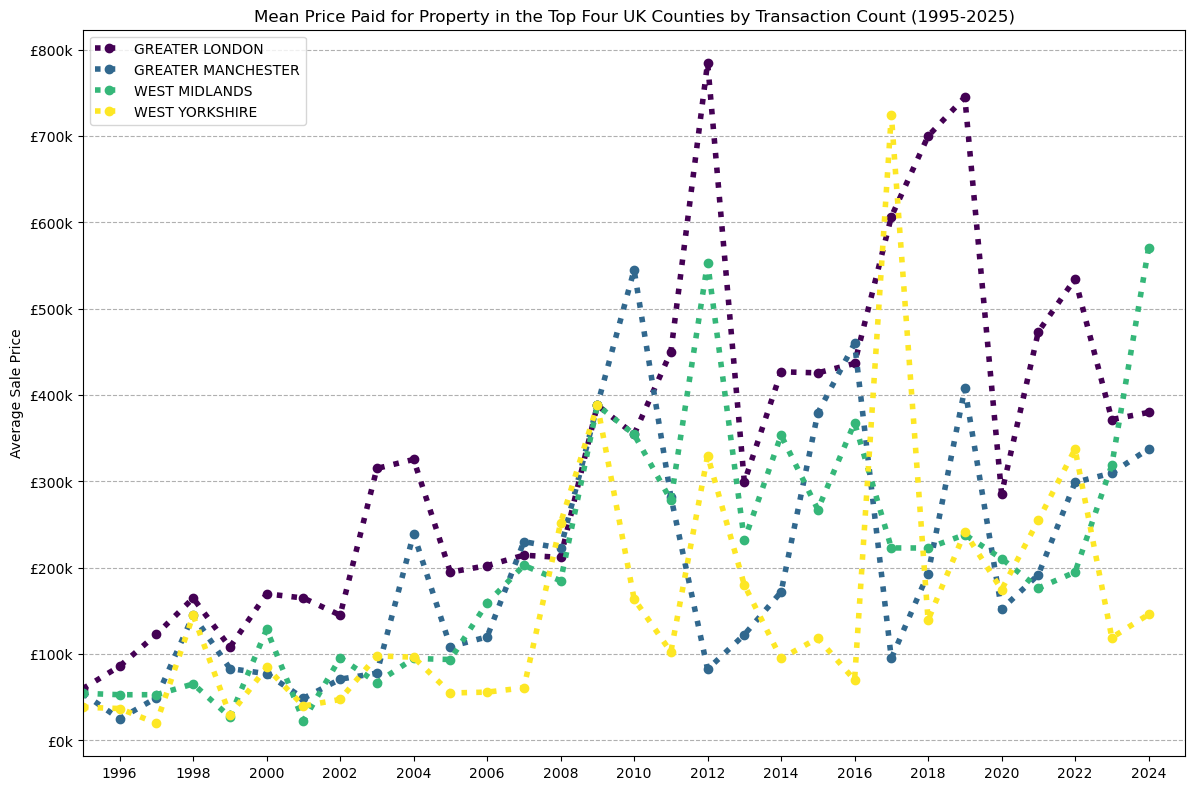

In [41]:
fig, ax = plt.subplots()

df_pivot.T.plot( # .T.transposes the DF to swap the X & Y axis.
   kind='line',
    linewidth=4,
    linestyle=':', # options: '-', '--' '-.', ':'
     colormap='viridis', #loads of options
     marker='o', #loads of options like '*' etc
     markersize=6,
     figsize=(12,8),
     ax=ax
    )
plt.tight_layout()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'£{int(y/1000)}k')) # Formats the Y ticks to £100k etc
plt.legend(title='', loc='upper left')
plt.grid(axis='y', linestyle="--") #Grid & linestyle of grid.
plt.title(f'{average_type} Price Paid for Property in the Top Four UK Counties by Transaction Count (1995-2025)')
plt.ylabel('Average Sale Price')
plt.xlabel('')
plt.locator_params(axis='x', nbins=16) 
plt.xlim(1995, 2025)
plt.show()